In [11]:
import numpy as np

In [3]:
import pandas as pd

# Read CSV files first
patients = pd.read_csv('patients.csv')
diagnoses = pd.read_csv('diagnoses.csv')
outcomes = pd.read_csv('outcomes.csv')
labs = pd.read_csv('labs.csv')



In [4]:
# Merge data
patients = patients.merge(diagnoses, on='DiagnosisID')
patients = patients.merge(outcomes, on='OutcomeID')

In [5]:
patients['AdmissionDate'] = pd.to_datetime(patients['AdmissionDate'])
patients['DischargeDate'] = pd.to_datetime(patients['DischargeDate'])
patients['LengthOfStay'] = (patients['DischargeDate'] - patients['AdmissionDate']).dt.days

In [9]:
patients['OutcomeEncoded'] = patients['OutcomeName'].map({
    'Recovered': 0,
    'Complicated': 1,
    'Deceased': 1
})

In [15]:

patients['HighRisk'] = np.where(
    (patients['Age'] > 65) &
    (patients['OutcomeName'].isin(['Complicated', 'Deceased'])),
    1,
    0
)

In [14]:
abnormal_conditions = {
    'Blood Sugar': lambda x: x > 120,
    'Cholesterol': lambda x: x > 200,
    'Hemoglobin': lambda x: x < 13
}

def count_abnormal_labs(patient_id):
    patient_labs = labs[labs['PatientID'] == patient_id]

    count = 0

    for test_name, condition in abnormal_conditions.items():
        test_results = patient_labs[
            patient_labs['TestName'] == test_name
        ]

        count += test_results['Result'].apply(condition).sum()

    return count

patients['AbnormalLabCount'] = patients['PatientID'].apply(count_abnormal_labs)

MODEL TRAINING

In [24]:
features = ['Age', 'LengthOfStay', 'AbnormalLabCount', 'TreatmentCost']
target = patients['OutcomeEncoded']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.3,
    random_state=42
)

ML-

1. supervised - input + output - Linear Regression, Logistic Regression etc

2. unsupervised - input

3. reinforcement - rewards

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 500)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Classification Report:")

print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.93      0.84        41
           1       0.70      0.37      0.48        19

    accuracy                           0.75        60
   macro avg       0.73      0.65      0.66        60
weighted avg       0.74      0.75      0.72        60



ROC CURVE

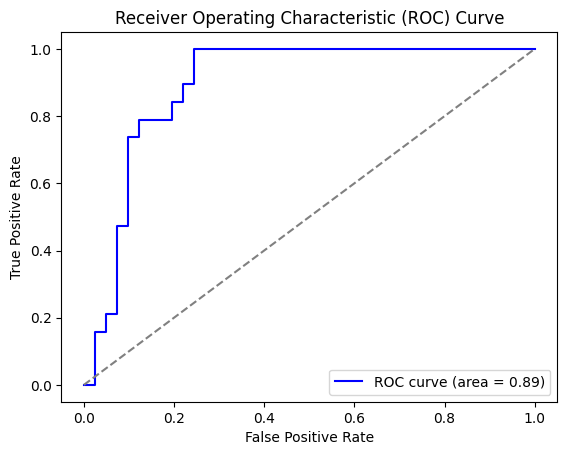

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', label = f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [32]:
import joblib
joblib.dump(model, 'risk_model.ipynb')

['risk_model.ipynb']

In [33]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [36]:
import streamlit as st
import pandas as pd
import joblib

# Load trained model
model = joblib.load('Risk_model1.pkl')

st.title("Healthcare Risk Stratification App")

# Input fields
age = st.number_input("Age", min_value=0, value=25)
length_of_stay = st.number_input("Length of Stay (days)", min_value=0, value=1)
treatment_cost = st.number_input("Treatment Cost", min_value=0.0, value=1000.0)

# Predict button
if st.button("Predict"):

    input_data = pd.DataFrame(
        [[age, length_of_stay, treatment_cost]],
        columns=['Age', 'LengthOfStay', 'TreatmentCost']
    )

    prediction = model.predict(input_data)[0]
    
    st.subheader("Prediction Result")

    if prediction == 1:
        st.error("High Risk Patient")
    else:
        st.success("Low Risk Patient")

    # Show probability only if model supports it
    if hasattr(model, "predict_proba"):
        probability = model.predict_proba(input_data)[0][1]
        st.write(f"Risk Probability: {probability*100:.2f}%")

EOFError: 